            Sales
Date             
2018-01-31    150
2018-02-28    165
2018-03-31    180
2018-04-30    195
2018-05-31    210


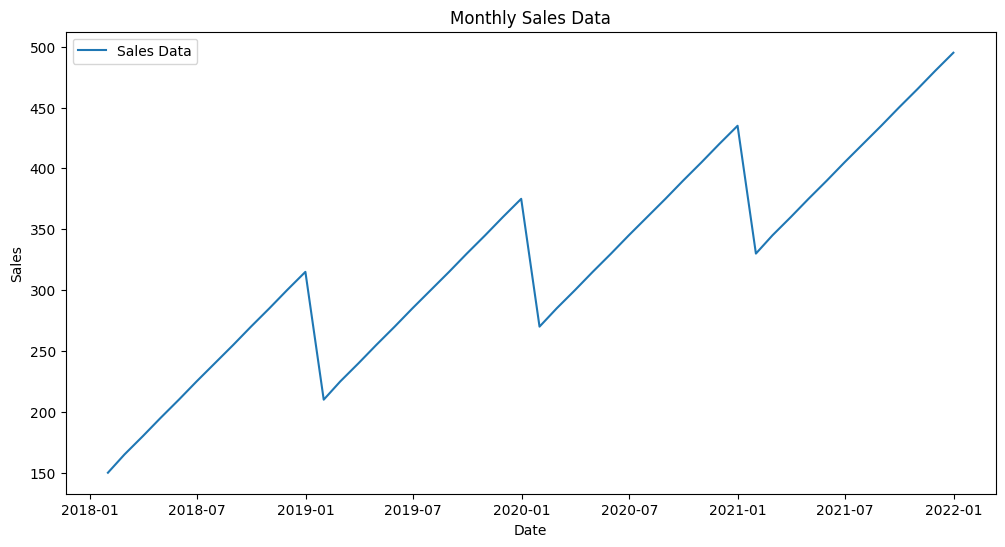

ADF Statistic: -1.2229703810557706
p-value: 0.663637211890853
The data is not stationary. Applying differencing to make it stationary.


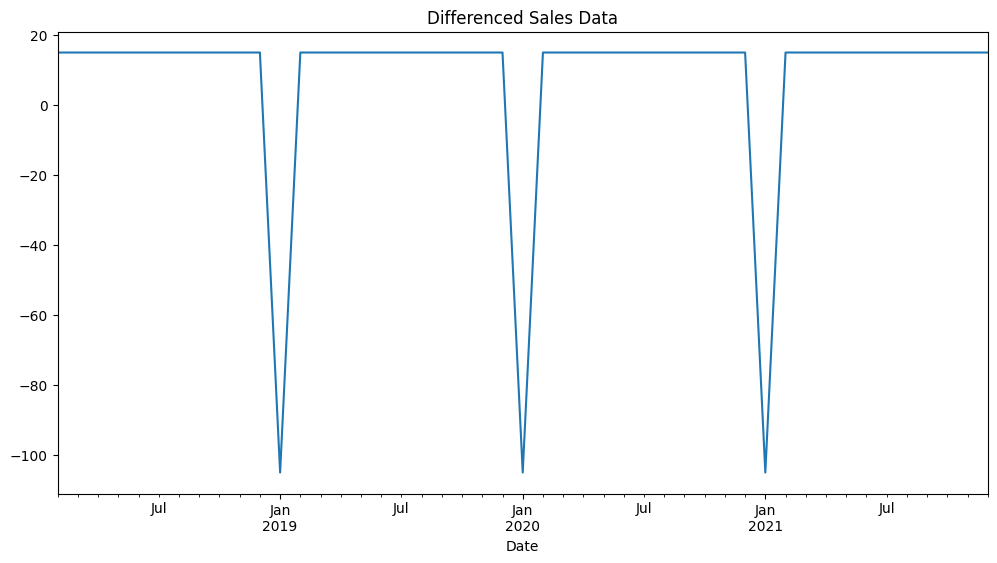

c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -226.871
Date:                Fri, 01 Nov 2024   AIC                            459.742
Time:                        14:39:38   BIC                            465.292
Sample:                    01-31-2018   HQIC                           461.830
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7069      4.690      0.151      0.880      -8.485       9.899
ma.L1         -0.7404      4.589     -0.161      0.872      -9.736       8.255
sigma2       912.3754    481.584      1.895      0.0

C:\Users\91742\AppData\Local\Temp\ipykernel_7596\2889676414.py:50: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(start=df.index[-1], periods=forecast_steps + 1, freq='M')[1:], forecast, label='Forecast', color='red')


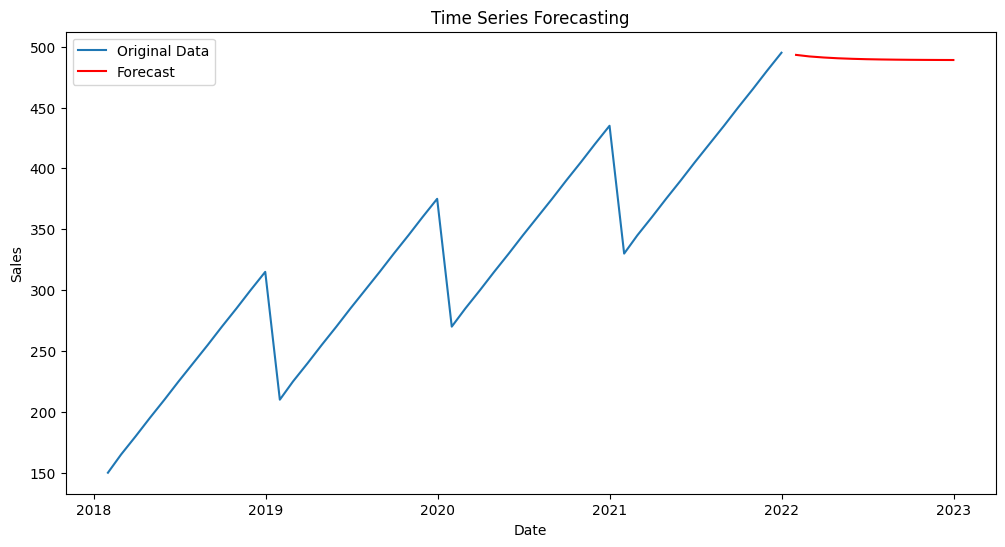

c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


Mean Squared Error on Test Set: 7399.091170965903


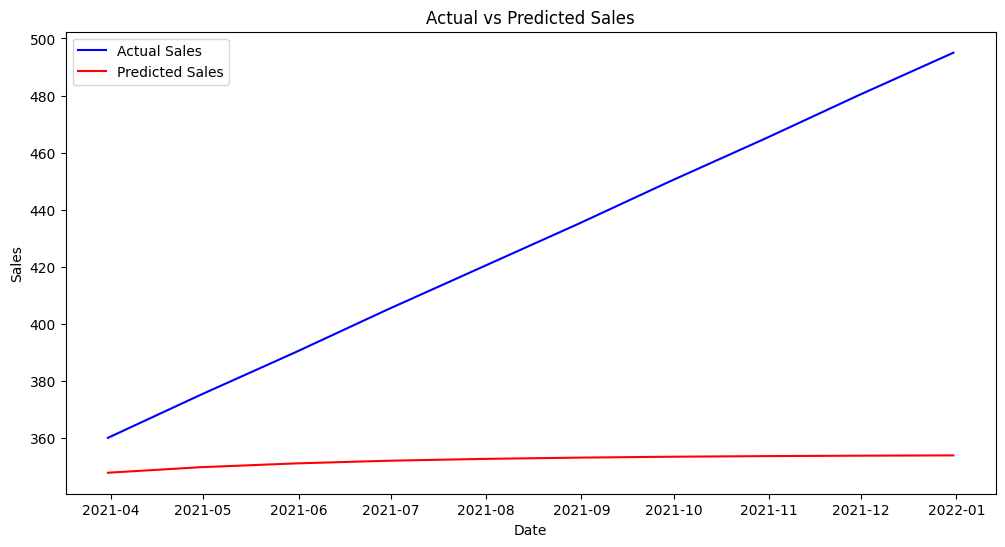

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

# Function to perform time series analysis and forecasting
def time_series_analysis(file_path):
    # Step 1: Load and visualize the data
    df = pd.read_excel(file_path, parse_dates=['Date'], index_col='Date')
    print(df.head())

    # Plot the time series data
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Sales'], label='Sales Data')
    plt.title('Monthly Sales Data')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.show()

    # Step 2: Check for stationarity using the Augmented Dickey-Fuller test
    result = adfuller(df['Sales'])
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The data is stationary.")
    else:
        print("The data is not stationary. Applying differencing to make it stationary.")

    # Step 3: Make the data stationary if necessary
    df['Sales_Diff'] = df['Sales'].diff()
    df['Sales_Diff'].dropna().plot(figsize=(12, 6), title='Differenced Sales Data')
    plt.show()

    # Step 4: Build and train the ARIMA model
    model = ARIMA(df['Sales'], order=(1, 1, 1))
    model_fit = model.fit()
    print(model_fit.summary())

    # Step 5: Forecast future values
    forecast_steps = 12
    forecast = model_fit.forecast(steps=forecast_steps)

    # Plot the forecast
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Sales'], label='Original Data')
    plt.plot(pd.date_range(start=df.index[-1], periods=forecast_steps + 1, freq='M')[1:], forecast, label='Forecast', color='red')
    plt.title('Time Series Forecasting')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.show()

    # Step 6: Model evaluation
    train_size = int(len(df) * 0.8)
    train, test = df['Sales'][:train_size], df['Sales'][train_size:]

    # Retrain ARIMA on the training set
    model = ARIMA(train, order=(1, 1, 1))
    model_fit = model.fit()
    test_forecast = model_fit.forecast(steps=len(test))

    # Calculate Mean Squared Error
    mse = mean_squared_error(test, test_forecast)
    print("Mean Squared Error on Test Set:", mse)

    # Plot Actual vs. Predicted values
    plt.figure(figsize=(12, 6))
    plt.plot(test.index, test, label='Actual Sales', color='blue')
    plt.plot(test.index, test_forecast, label='Predicted Sales', color='red')
    plt.title('Actual vs Predicted Sales')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.show()
# Example usage:
# Replace 'monthly_sales_data.csv' with the path to your own data file
file_path = 'monthly_sales_data.xlsx'
time_series_analysis(file_path)
